# **Model Training and Evaluation**

In fraud detection, a model that simply guesses "Not Fraud" for every transaction will achieve 99%+ accuracy but catch 0% of the thieves. This is called the Accuracy Paradox.

To fix this, we need to move beyond simple training and use Cost-Sensitive Learning.

In [1]:
# import necessary libraries
from pathlib import Path

# data manipulation libraries
import pandas as pd
import numpy as np

# data preprocessing 
from sklearn.model_selection import train_test_split

# machine learning model
from xgboost import XGBClassifier

# evaluation metrics
from sklearn.metrics import (
    classification_report,
    average_precision_score, 
    precision_recall_curve
)

## Prepare the data

In [2]:
# Load the dataset
file_generator = Path.cwd().parent.rglob("v1.0_fraud_features_ready.csv")
file_path = list(file_generator)[0]
df = pd.read_csv(file_path)

# Separate features and target variable
X = df[[
    #'timestamp', 
    
    # 'user_id', #'device_id',
    
    'amount',  
    
    'lat', 'lon',
    
    #'ip_address', 'is_fraud', 
    
    'hour', 'day_of_week', 
    
    'tx_count_24h', 'avg_spend_user', 
    'amount_ratio', 
    
    'dist_from_last_tx_km', 'travel_velocity_kmph', 
    
    'auth_method_PIN', 'auth_method_Password',
    
    'category_food', 'category_grocery', 
    'category_tech', 'category_travel',
    'category_utilities'
]]

y = df['is_fraud']

## Split the data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

## Calculate the Scale Weight
- Basically we are calculating the ratio of negative cases to positive cases. 
- This will be used in `scale_pos_weight` parameter of xgboost algo to declare how much imbalanced the data is.

In [4]:
imbalance_ratio = (len(y_train) - y_train.sum()) / len(y_train)

## Train the model

**The Strategy: XGBoost + scale_pos_weight**

Regular models will underfit the fraud cases and achieve the 99% accuracy. Since it's a special case of underfitting(underfits a different subset of data) we need a boosting algorithm, that can be directed to focus on this minority subset of data more than the other.

>In 2026, the industry standard for tabular data like this is XGBoost. It has a built-in hyperparameter called `scale_pos_weight` that tells the model: "Paying attention to the 2% of fraud cases is 50x more important than the 98% of legitimate ones."

In [5]:
# Initiate the model with parameter
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05, 
    subsample=0.8, # Use 80% of data for each tree
    colsample_bytree=0.8, # Use 80% of features
    scale_pos_weight=imbalance_ratio, # Handle class imbalance
    tree_method="hist", # Use histogram-based algorithm for faster training
    eval_metric="aucpr", # Use AUC-PR for evaluation
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Evaluate the model

### Predict probabilities
Q. Why probabilities matters more than predictions?

A. Because of the complicate nature of the real world our model will make mistakes. So making a binary decision based on that is saying like since the probability of fraud for transaction A is 0.4999999 that means it's not fraud, but the probability of fraud for transaction B is 0.5000001 that means it's a fraud. --We can see the ridiculusness of that statement.

Also binary prediction is non-negotiable, you can't intervene in the decision making process.

But with the help of probability, we can set a threshold/decision boundary beyond which we can categorize a transaction is fraud. It also grant us the flexibity of changing this threshold according to our needs.


In [6]:
y_probs = model.predict_proba(X_test)[:,1]

### Business-cost-aware Thresholding 
Q. Why is this necessary?

A. Our model will make mistakes. But not catching a fraud is much more deadly than blocking a legitamite transaction.

But Xgboost treats both of these mistakes equally, if we continue to do so we will loose a lot of money(primary concern for business). So we need a custom cost function that prioritize catching fraud and decide a threshold based on that.

The threshold/decision boundary for the xgboost algo is 0.50, and we know how ridiculus that is. 

In [7]:
# Optimize threshold based on cost
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # project root

# import threshold optimization functions
from src.threshold_optimization import (
    find_optimal_threshold,
    save_threshold,
)

# Find the optimal threshold
threshold_info = find_optimal_threshold(
    y_true=y_test.to_numpy(),
    y_prob=y_probs,
    cost_fp=1.0,
    cost_fn=10.0
)


# Save the optimal threshold
save_threshold(
    threshold_info=threshold_info,
    path=Path.cwd().parent / "artifacts" / "model" / "optimal_threshold.json",
)

PATH = Path.cwd().parent / "artifacts" / "model"

# Load the optimal threshold
import json

with open(PATH / "optimal_threshold.json") as f:
    best_threshold = json.load(f)["best_threshold"]

### Final Predictions

In [8]:
# Make final predictions using the optimal threshold
y_pred_final = (y_probs >= best_threshold).astype(int)

### Evaluation with metrics
We will ignore Accuracy. Instead, we focus on:

- Precision-Recall AUC (PR-AUC): Better than ROC-AUC for imbalanced data.

- Recall: What percentage of actual fraud did we catch?

- F1-Score: The balance between catching fraud and not annoying real customers.

In [9]:
print("Best Threshold:", round(best_threshold, 3))
print("PR-AUC:", round(average_precision_score(y_test, y_probs), 4))
print(classification_report(y_test, y_pred_final))

Best Threshold: 0.84
PR-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1968
           1       1.00      1.00      1.00        32

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# **Drift detection**
Q. Why is this needed?

A. Change is the only constant. Fraudsters will invent new tricks, and if we stick to the old model, we will get defeated. 

We have to be aware of their change of tactics, and it will show up in the data. This change is called drift(different new data), we have to keep track of this. We track this by looking at the new data, analysing it, and training models with this new data. 

-In conclusion, this is to check for difference in data. Because model perform good on old data but when new data arrives it fails(not all time) to predict things.

In [10]:
numerical_features = pd.DataFrame(X).select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = pd.DataFrame(X).select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

from src.monitoring import generate_monitoring_report

generate_monitoring_report(
    model=model,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    numerical_features=numerical_features,
    categorical_features=categorical_features
)

d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Data Science\Projects\

Train–Test Drift Monitoring
Status      : PASS
Drift score : 0.00
Report      : D:\Data Science\Projects\Real_Time_Fraud_Detection_System\reports\drift_monitoring\drift_report_20260201_150545.html


{'status': 'PASS',
 'drift_score': 0.0,
 'report_path': 'D:\\Data Science\\Projects\\Real_Time_Fraud_Detection_System\\reports\\drift_monitoring\\drift_report_20260201_150545.html'}

# **Model Explainability (SHAP)**
We use SHAP (SHapley Additive ExPlanations) to show exactly which feature triggered the fraud alert.

d:\Data Science\Projects\Real_Time_Fraud_Detection_System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



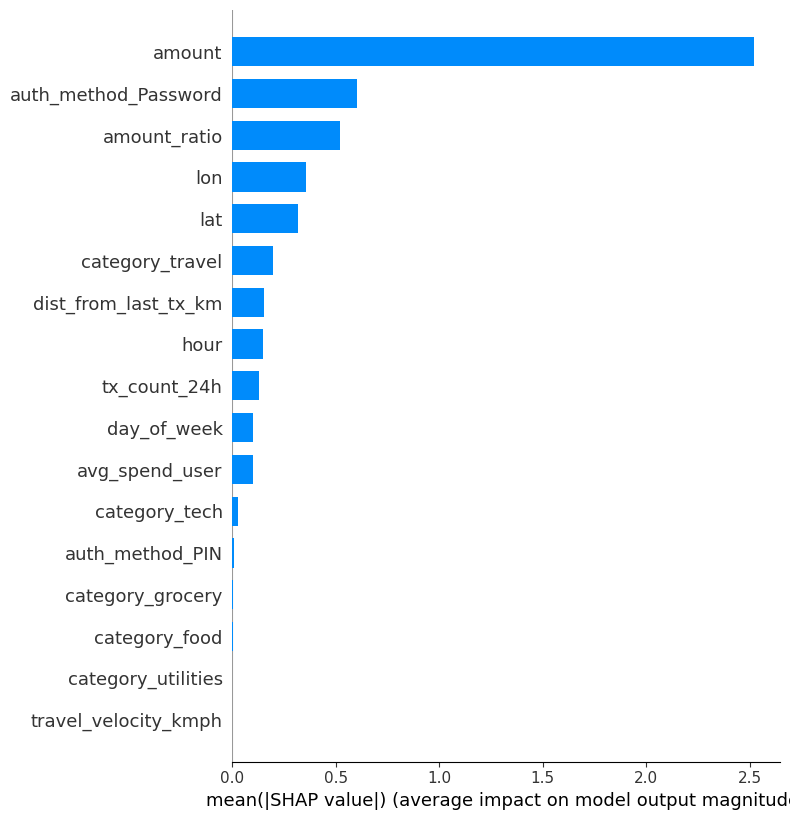

In [11]:
import shap

# Calculate SHAP values for the test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot top features that drive fraud
shap.summary_plot(shap_values, X_test, plot_type="bar")

# **Save the Model**

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "artifacts" / "model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
# Save this in training script
model.save_model(MODEL_DIR / "v1.0_xgb_fraud_detection_model.json")